In [15]:
from ke_toolbox.utils import get_default_device
import torch
import matplotlib.pyplot as plt
from ke_toolbox.dataset import prepare_dataset
import seaborn as sns
from ke_toolbox.main import optimize_step1_beta, optimize_step2_alpha
import numpy as np
device = get_default_device()

# dont print any warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Falling back to CPU.


## Concentric Circles

In [ ]:
# Generate train data
from ke_toolbox.utils import generate_concentric_circles

# Heavier noise, fewer samples on the outer ring
X_train, y_train = generate_concentric_circles(
    samples_per_circle=[80, 110, 190],
    radii=[2, 8, 16],
    noise_std=0.5,          # blur the circles a lot
    seed=0               # new random draw each call
)

#Normalize the data between 0 and 1

X_train = (X_train - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0))
# Convert NumPy array to PyTorch tensor
X_tr = torch.tensor(X_train, dtype=torch.float32, device=device)


In [3]:

seed = 0
# Step 1 (β)
kernel_type_reconstruction="rbf"
sigma_reconstruction=1
num_iters_beta=50000
lr_beta=0.001
beta_solver="exact" # "exact" or "gd"
plot_loss_curve_b=False

# Step 2 (α)
kernel_type_embedding="rbf"
sigma_embedding=0.01
num_iters_alpha=30000
lr_alpha=0.005
latent_dim=1
plot_loss_curve_a=False
plot=True

# — Step 1: β ————————————————————————————————————————————————
beta, K_precomputed, _ = optimize_step1_beta(
    X=X_tr,
    device=device,
    kernel_type=kernel_type_reconstruction,
    sigma=sigma_reconstruction,
    beta_solver=beta_solver,
    num_iters=num_iters_beta,
    lr=lr_beta,
    seed=seed,
    plot_every=0,
    plot_loss_curve =plot_loss_curve_b
)

# — Step 2: α ————————————————————————————————————————————————
alpha, kernel_fn_alpha, _ = optimize_step2_alpha(
    X=X_tr,
    device=device,
    kernel_type=kernel_type_embedding,
    sigma=sigma_embedding,
    num_iters=num_iters_alpha,
    lr=lr_alpha,
    latent_dim=latent_dim,
    beta=beta,
    K_precomputed=K_precomputed,   # ← needed for α-mode
    seed=seed,
    plot_every=0,
    plot_loss_curve=plot_loss_curve_a
)

# — Optional visualisation ————————————————————————————————
print("[Step 3] Plotting heat-maps and latent scatter …")
K_orig_np = K_precomputed.cpu().numpy()
Z = (alpha @ K_precomputed).T
K_latent = kernel_fn_alpha(Z).cpu().numpy()
H = Z.cpu().numpy(); y_np = y_train


[Step 1] Optimising β …
Step 1 complete – final β-loss: 3.589771e+01

[Step 2] Optimising α …
[α-Adam] 1000  loss=3.733e+02  lr=5.0e-03
[α-Adam] 2000  loss=3.722e+02  lr=1.3e-03
[α-Adam] 3000  loss=3.700e+02  lr=3.1e-04
[α-Adam] 4000  loss=2.960e+02  lr=7.8e-05
[α-Adam] 5000  loss=2.960e+02  lr=2.0e-05
[α-Adam] 6000  loss=2.960e+02  lr=4.9e-06
[α-Adam] 7000  loss=2.959e+02  lr=1.2e-06
[α-Adam] 8000  loss=2.959e+02  lr=1.0e-06
[α-Adam] 9000  loss=2.959e+02  lr=1.0e-06
[α-Adam] 10000  loss=2.959e+02  lr=1.0e-06
[α-Adam] 11000  loss=2.959e+02  lr=1.0e-06
[Early Stop] no improvement; breaking
Step 2 complete – final α-loss: 2.959122e+02
Latent representation shape: torch.Size([1, 380])
[Step 3] Plotting heat-maps and latent scatter …


2025-05-06 11:17:20.606955: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746523040.619496  223915 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746523040.623244  223915 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-06 11:17:20.637914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


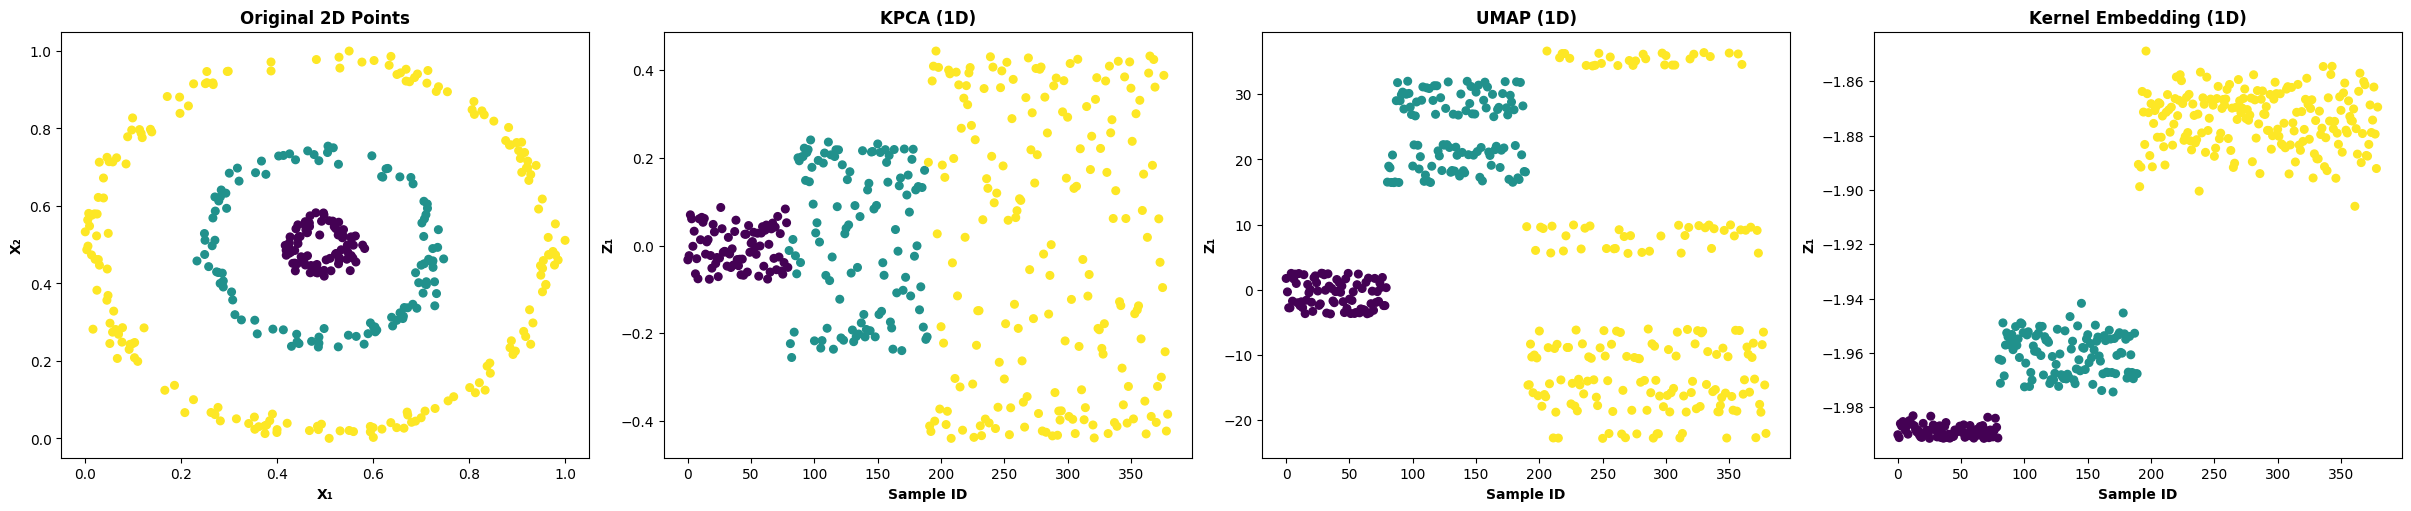

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA, KernelPCA as KPCA
import umap.umap_ as umap

# Example data (replace with your own)
ids = np.arange(X_train.shape[0])

# Compute embeddings
pca = KPCA(kernel="precomputed", n_components=1)
X_train_pca = pca.fit_transform(K_orig_np)
umap_model = umap.UMAP(n_components=1, random_state=42)
X_train_umap = umap_model.fit_transform(X_train)

# Plot settings
fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
cmap = plt.cm.viridis
scatter_kwargs = dict(c=y_train, cmap=cmap, s=30, alpha=1)

# Original 2D
axes[0].scatter(X_train[:, 0], X_train[:, 1], **scatter_kwargs)
axes[0].set_xlabel("X₁", fontweight='bold')
axes[0].set_ylabel("X₂", fontweight='bold')
axes[0].set_title("Original 2D Points", fontweight='bold')

# KPCA
axes[1].scatter(ids, X_train_pca[:, 0], **scatter_kwargs)
axes[1].set_xlabel("Sample ID", fontweight='bold')
axes[1].set_ylabel("Z₁", fontweight='bold')
axes[1].set_title("KPCA (1D)", fontweight='bold')

# UMAP
axes[2].scatter(ids, X_train_umap[:, 0], **scatter_kwargs)
axes[2].set_xlabel("Sample ID", fontweight='bold')
axes[2].set_ylabel("Z₁", fontweight='bold')
axes[2].set_title("UMAP (1D)", fontweight='bold')

# Kernel Embedding
axes[3].scatter(ids, H[:, 0], **scatter_kwargs)
axes[3].set_xlabel("Sample ID", fontweight='bold')
axes[3].set_ylabel("Z₁", fontweight='bold')
axes[3].set_title("Kernel Embedding (1D)", fontweight='bold')

plt.show()

# Save the figure
fig.savefig("cc_embedding_comparison.png", dpi=600, bbox_inches='tight')

In [5]:
# Compute DAVIES-BOULDING index.
from sklearn.metrics import davies_bouldin_score

# Compute Davies-Bouldin index for the original data
db_original = davies_bouldin_score(X_train, y_train)

# Compute Davies-Bouldin index for the PCA representation
db_pca = davies_bouldin_score(X_train_pca, y_train)

# Compute Davies-Bouldin index for the UMAP representation
db_umap = davies_bouldin_score(X_train_umap, y_train)

# Compute Davies-Bouldin index for the Kernel embedding
db_kernel_embedding = davies_bouldin_score(H, y_train)

print("Davies-Bouldin index for the original data:", db_original)
print("Davies-Bouldin index for the PCA representation:", db_pca)
print("Davies-Bouldin index for the UMAP representation:", db_umap)
print("Davies-Bouldin index for the Kernel embedding:", db_kernel_embedding)

# Compute CHI index.
from sklearn.metrics import calinski_harabasz_score

# Compute Calinski-Harabasz index for the original data
ch_original = calinski_harabasz_score(X_train, y_train)

# Compute Calinski-Harabasz index for the PCA representation
ch_pca = calinski_harabasz_score(X_train_pca, y_train)

# Compute Calinski-Harabasz index for the UMAP representation
ch_umap = calinski_harabasz_score(X_train_umap, y_train)

# Compute Calinski-Harabasz index for the Kernel embedding
ch_kernel_embedding = calinski_harabasz_score(H, y_train)

print("Calinski-Harabasz index for the original data:", ch_original)
print("Calinski-Harabasz index for the PCA representation:", ch_pca)
print("Calinski-Harabasz index for the UMAP representation:", ch_umap)
print("Calinski-Harabasz index for the Kernel embedding:", ch_kernel_embedding)



Davies-Bouldin index for the original data: 23.302256299209777
Davies-Bouldin index for the PCA representation: 43.15507106221361
Davies-Bouldin index for the UMAP representation: 9.367592891797356
Davies-Bouldin index for the Kernel embedding: 0.2523711025389367
Calinski-Harabasz index for the original data: 0.3946042459913443
Calinski-Harabasz index for the PCA representation: 0.49016398
Calinski-Harabasz index for the UMAP representation: 142.21275
Calinski-Harabasz index for the Kernel embedding: 6519.464


## Swiss roll

In [6]:
dataset_name="swiss_roll"
dataset_path="data/swiss_roll.mat"
subset_ratio=1.0
seed=0

# Step 1 (β)
kernel_type_reconstruction="rbf"
sigma_reconstruction=0.5
num_iters_beta=50000
beta_solver="exact" # "exact" or "gd"
plot_loss_curve_b=False

# Step 2 (α)
kernel_type_embedding="rbf"
sigma_embedding=0.25
num_iters_alpha=1000
lr_alpha=0.5
latent_dim=2
plot_loss_curve_a=False

print(f"Preparing dataset ‘{dataset_name}’ from {dataset_path} …")
X, y, device = prepare_dataset(
    path=dataset_path,
    subset_ratio=subset_ratio,
    normalize=True,
    seed=seed,
)

seed = 0

print(f"Device: {device}  |  X shape: {X.shape}  X Device: {X.device} |  y shape: {y.shape}")

# — Step 1: β ————————————————————————————————————————————————
beta, K_precomputed, loss_beta = optimize_step1_beta(
    X=X,
    device=device,
    kernel_type=kernel_type_reconstruction,
    sigma=sigma_reconstruction,
    beta_solver=beta_solver,
    num_iters=num_iters_beta,
    seed=seed,
    plot_every=0,
    plot_loss_curve =plot_loss_curve_b
)

# — Step 2: α ————————————————————————————————————————————————
alpha, kernel_fn_alpha, loss_alpha = optimize_step2_alpha(
    X=X,
    device=device,
    kernel_type=kernel_type_embedding,
    sigma=sigma_embedding,
    num_iters=num_iters_alpha,
    lr=lr_alpha,
    latent_dim=latent_dim,
    beta=beta,
    K_precomputed=K_precomputed,   # ← needed for α-mode
    seed=seed,
    plot_every=0,
    plot_loss_curve=plot_loss_curve_a
)

print("[Step 3] Plotting heat-maps and latent scatter …")
K_orig_np = K_precomputed.cpu().numpy()
Z = (alpha @ K_precomputed).T
K_latent = kernel_fn_alpha(Z).cpu().numpy()
H = Z.cpu().numpy(); y_np = y.cpu().numpy()

Preparing dataset ‘swiss_roll’ from data/swiss_roll.mat …
Using CUDA device for all tensors by default.
Device: cuda  |  X shape: torch.Size([2000, 3])  X Device: cuda:0 |  y shape: torch.Size([2000, 1])

[Step 1] Optimising β …
Step 1 complete – final β-loss: 5.348040e+02

[Step 2] Optimising α …
[α-Adam] 1000  loss=1.859e+03  lr=2.5e-01
Step 2 complete – final α-loss: 1.858908e+03
Latent representation shape: torch.Size([2, 2000])
[Step 3] Plotting heat-maps and latent scatter …


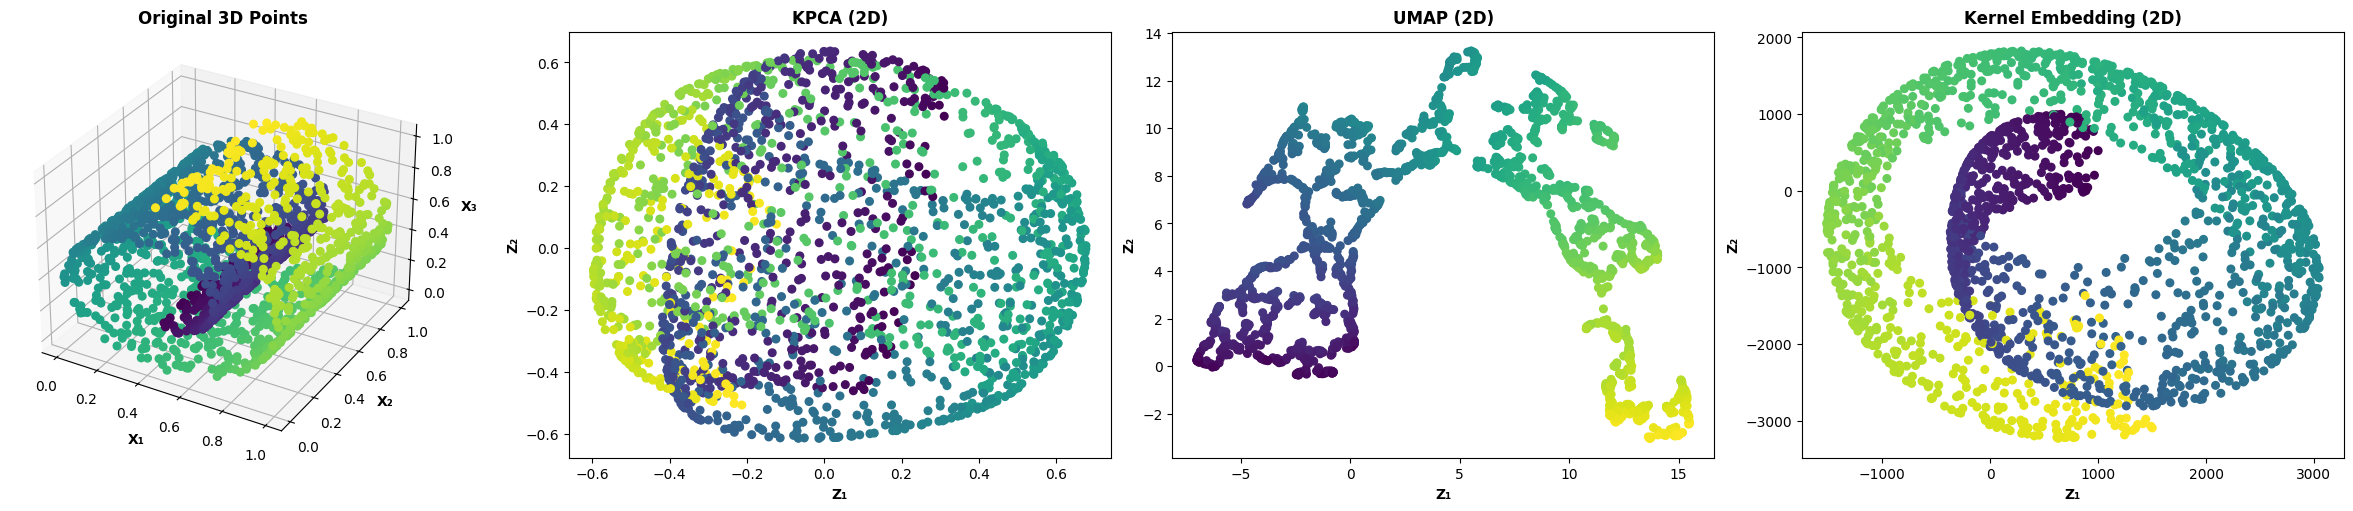

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA, KernelPCA as KPCA
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D  # Enables 3D plotting

Xtr = X.cpu().numpy()
y_train = y.cpu().numpy()

# Compute 2D embeddings
pca = PCA(n_components=2)

# USE Kernel PCA precomputed kernel
pca = KPCA(kernel="precomputed", n_components=2)
X_train_pca = pca.fit_transform(K_orig_np)

umap_model = umap.UMAP(n_components=2, random_state=42)
X_train_umap = umap_model.fit_transform(Xtr)

# Plot settings
fig = plt.figure(figsize=(24, 5), constrained_layout=True)
cmap = plt.cm.viridis
scatter_kwargs = dict(c=y_train, cmap=cmap, s=30, alpha=1)

# 3D original data
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(Xtr[:, 0], Xtr[:, 1], Xtr[:, 2], **scatter_kwargs)
ax1.set_xlabel("X₁", fontweight='bold')
ax1.set_ylabel("X₂", fontweight='bold')
ax1.set_zlabel("X₃", fontweight='bold')
ax1.set_title("Original 3D Points", fontweight='bold')

# KPCA 2D
ax2 = fig.add_subplot(1, 4, 2)
ax2.scatter(X_train_pca[:, 0], X_train_pca[:, 1], **scatter_kwargs)
ax2.set_xlabel("Z₁", fontweight='bold')
ax2.set_ylabel("Z₂", fontweight='bold')
ax2.set_title("KPCA (2D)", fontweight='bold')

# UMAP 2D
ax3 = fig.add_subplot(1, 4, 3)
ax3.scatter(X_train_umap[:, 0], X_train_umap[:, 1], **scatter_kwargs)
ax3.set_xlabel("Z₁", fontweight='bold')
ax3.set_ylabel("Z₂", fontweight='bold')
ax3.set_title("UMAP (2D)", fontweight='bold')

# Kernel embedding (2D)
ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(H[:, 0], H[:, 1], **scatter_kwargs)
ax4.set_xlabel("Z₁", fontweight='bold')
ax4.set_ylabel("Z₂", fontweight='bold')
ax4.set_title("Kernel Embedding (2D)", fontweight='bold')

plt.show()
fig.savefig("swiss_roll_embedding_comparison.png", dpi=600, bbox_inches='tight')


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness

def continuity(X_orig, X_emb, n_neighbors=10):
    """
    Compute Continuity: how well neighbors in original space are preserved in the embedding.

    Parameters:
        X_orig : np.ndarray
            Original high-dimensional input data, shape (n_samples, d).
        X_emb : np.ndarray
            Low-dimensional embedding, shape (n_samples, p).
        n_neighbors : int
            Number of nearest neighbors to consider.

    Returns:
        float
            Continuity score in [0, 1].
    """
    n_samples = X_orig.shape[0]

    # Distance matrices
    dist_orig = pairwise_distances(X_orig)
    dist_emb = pairwise_distances(X_emb)

    # Get indices of k-nearest neighbors
    neighbors_orig = np.argsort(dist_orig, axis=1)[:, 1:n_neighbors+1]
    neighbors_emb = np.argsort(dist_emb, axis=1)[:, 1:n_neighbors+1]

    # Compute ranks in the embedded space
    ranks_emb = np.argsort(np.argsort(dist_emb, axis=1), axis=1)

    # Penalty for missing original neighbors in the embedding
    penalty = 0.0
    for i in range(n_samples):
        for j in neighbors_orig[i]:
            if j not in neighbors_emb[i]:
                penalty += (ranks_emb[i, j] - n_neighbors + 1) ** 2

    norm = n_neighbors * n_samples * (2 * n_samples - 3 * n_neighbors - 1)
    continuity_score = 1 - (2 / norm) * penalty
    return continuity_score


embeddings = {
    'KPCA': X_train_pca,
    'UMAP': X_train_umap,
    'Kernel Embedding': H
}

# Compute Trustworthiness and Continuity
results = []
n_neighbors = 15
for method, Z in embeddings.items():
    trust = trustworthiness(Xtr, Z, n_neighbors=n_neighbors)
    cont = continuity(Xtr, Z, n_neighbors=n_neighbors)
    results.append({
        'Method': method,
        'Trustworthiness': round(trust, 4),
        'Continuity': round(cont, 4)
    })

df_metrics = pd.DataFrame(results)
print(df_metrics)

             Method  Trustworthiness  Continuity
0              KPCA           0.8617      0.7496
1              UMAP           0.9990      0.1769
2  Kernel Embedding           0.9061      0.6118


## Cancer NCI

In [9]:
from tqdm.contrib.concurrent import process_map
from sklearn.svm import NuSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix
)
from functools import partial
import numpy as np
import pandas as pd

def process_cancer_type(class_idx, K_latent, Y_np, nus, cv):
    y_binary = Y_np[:, class_idx].astype(int)
    if np.all(y_binary == 0) or np.all(y_binary == 1):
        return None, None

    best_auc = -1
    best_model = None
    best_stats = {}

    for nu in nus:
        fold_metrics = []

        for train_idx, test_idx in cv.split(K_latent, y_binary):
            K_train = K_latent[np.ix_(train_idx, train_idx)]
            K_test = K_latent[np.ix_(test_idx, train_idx)]
            y_train = y_binary[train_idx]
            y_test = y_binary[test_idx]

            try:
                clf = NuSVC(nu=nu, kernel="precomputed", probability=True, class_weight="balanced")
                clf.fit(K_train, y_train)
                y_pred = clf.predict(K_test)
                y_score = clf.predict_proba(K_test)[:, 1]
            except Exception:
                continue

            if len(np.unique(y_test)) < 2:
                continue

            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
            fold_metrics.append({
                "sensitivity": recall_score(y_test, y_pred),
                "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
                "precision": precision_score(y_test, y_pred),
                "f1_score": f1_score(y_test, y_pred),
                "accuracy": accuracy_score(y_test, y_pred),
                "roc_auc": roc_auc_score(y_test, y_score)
            })

        if not fold_metrics:
            continue

        auc_mean = np.mean([m["roc_auc"] for m in fold_metrics])

        if auc_mean > best_auc:
            best_stats = {
                "class": class_idx,
                "nu": nu,
            }
            for metric in fold_metrics[0].keys():
                values = [fm[metric] for fm in fold_metrics]
                best_stats[f"{metric}_mean"] = np.mean(values)
                best_stats[f"{metric}_std"] = np.std(values)

            full_clf = NuSVC(nu=nu, kernel="precomputed", probability=True, class_weight="balanced")
            full_clf.fit(K_latent, y_binary)
            best_model = full_clf
            best_auc = auc_mean

    return best_stats, best_model

def evaluate_kernel_with_nusvc(K_latent, Y_class, nus=[0.25, 0.5, 0.75], n_splits=5,print_metrics=True):
    """
    Evaluate a precomputed kernel K_latent using NuSVC for multi-label cancer classification.

    Parameters:
    - K_latent: np.ndarray, precomputed kernel matrix (n_samples x n_samples)
    - Y_class: np.ndarray or torch.Tensor, one-hot encoded labels (n_samples x n_classes)
    - nus: list of float, nu values to search over
    - n_splits: int, number of cross-validation folds

    Returns:
    - df_metrics: pd.DataFrame with per-class metrics (mean ± std)
    - best_models: dict mapping class index to best NuSVC model
    """
    Y_np = Y_class.cpu().numpy() if hasattr(Y_class, 'cpu') else Y_class
    n_classes = Y_np.shape[1]
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Wrap the processing function with shared arguments
    worker = partial(process_cancer_type, K_latent=K_latent, Y_np=Y_np, nus=nus, cv=cv)

    # Run in parallel with tqdm
    results = process_map(worker, range(n_classes), max_workers=None, chunksize=1)

    # Extract results
    metrics_list = [res[0] for res in results if res[0] is not None]
    best_models = {res[0]["class"]: res[1] for res in results if res[1] is not None}

    df_metrics = pd.DataFrame(metrics_list)
    if print_metrics:
        print("\nPer-cancer classification metrics (mean ± std over 5 folds):")
        print(df_metrics)

    # Global averages
    global_means = df_metrics[[c for c in df_metrics.columns if c.endswith("_mean")]].mean()
    global_stds = df_metrics[[c for c in df_metrics.columns if c.endswith("_std")]].mean()
    
    if print_metrics:
        # Print global averages
        print("\nGlobal average metrics across all valid cancer types:")
        for metric in global_means.index:
            name = metric.replace("_mean", "")
            mean_val = global_means[metric]
            std_val = global_stds[metric.replace("_mean", "_std")]
            print(f"{name:12s}: {mean_val:.4f} ± {std_val:.4f}")

    return df_metrics, best_models


In [ ]:
import numpy as np
import torch
file_names = ['ncicancer_input_kernel.txt',
            'ncicancer_bin_targets.txt',
            'ncicancer_targets.txt',
            'ncicancer_cancerCL_corr.txt']

data = []

' We import each dataset and append it to the list "data" '
for file in file_names:
    try:
        data.append(np.loadtxt('./data/NCI-CANCER/'+file))
        print('%s loaded.' %file)
    except:
        print('Error: %s not loaded.' %file)

X_gram = data[0]
Y_class = data[1]
Y_reg = data[2]
cancer_correls = data[3]

# Convert to tensors
X_gram = torch.tensor(X_gram, dtype=torch.float32)

ncicancer_input_kernel.txt loaded.
ncicancer_bin_targets.txt loaded.
ncicancer_targets.txt loaded.
ncicancer_cancerCL_corr.txt loaded.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from ke_toolbox.main import optimize_step1_beta, optimize_step2_alpha

seed = 42

# Step 1 (β)
kernel_type_reconstruction = "rbf"
beta_solver = "exact"

# Step 2 (α)
kernel_type_embedding = "rbf"
sigma_embedding = 0.5
num_iters_alpha = 3000
lr_alpha = 0.1

latent_dims = [2, 3, 5, 10, 20, 50, 100]
results_ke = []

for latent_dim in latent_dims:
    print(f"Latent dimension: {latent_dim}")

    # — Step 1: β —
    beta, K_precomputed, _ = optimize_step1_beta(
        X=torch.tensor([]),
        K_precomputed=X_gram,
        device=device,
        beta_solver=beta_solver,
        seed=seed,
    )

    # — Step 2: α —
    alpha, kernel_fn_alpha, _ = optimize_step2_alpha(
        X=torch.tensor([]),
        device=device,
        kernel_type=kernel_type_embedding,
        sigma=sigma_embedding,
        num_iters=num_iters_alpha,
        lr=lr_alpha,
        latent_dim=latent_dim,
        beta=beta,
        K_precomputed=K_precomputed,
        seed=seed,
        plot_every=0,
        plot_loss_curve=False
    )

    # Generate latent kernel with KE
    Z = (alpha @ K_precomputed).T
    K_latent = kernel_fn_alpha(Z).cpu().numpy()

    # Evaluate classification performance
    df_metrics_ke, _ = evaluate_kernel_with_nusvc(
        K_latent, Y_class,
        nus=[0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
        n_splits=5,
        print_metrics=False
    )

    df_metrics_ke["method"] = "KE"
    df_metrics_ke["latent_dim"] = latent_dim
    results_ke.append(df_metrics_ke)

# Concatenate KE results
df_all_ke = pd.concat(results_ke, ignore_index=True)

# Add F1 score to metrics
metrics = ["sensitivity", "specificity", "accuracy", "roc_auc", "f1_score"]

# Build summary table
summary_rows = []
for dim in latent_dims:
    df_subset = df_all_ke[df_all_ke["latent_dim"] == dim]
    summary = {"method": "KE", "latent_dim": dim}
    for m in metrics:
        mean_val = df_subset[f"{m}_mean"].mean()
        std_val = df_subset[f"{m}_mean"].std()
        summary[f"{m}_mean"] = mean_val
        summary[f"{m}_std"] = std_val
    summary_rows.append(summary)

df_summary = pd.DataFrame(summary_rows)

# Format mean ± std for display
for m in metrics:
    df_summary[f"{m}_combined"] = df_summary.apply(
        lambda row: f"{row[f'{m}_mean']:.3f} ± {row[f'{m}_std']:.3f}", axis=1
    )

# Display results
display_cols = ["latent_dim"] + [f"{m}_combined" for m in metrics]
print(df_summary[display_cols].to_string(index=False))

Latent dimension: 2

[Step 1] Optimising β …
Step 1 complete – final β-loss: 1.693901e+03

[Step 2] Optimising α …
[α-Adam] 1000  loss=1.758e+03  lr=5.0e-02
[α-Adam] 2000  loss=2.231e+03  lr=5.0e-02
[α-Adam] 3000  loss=2.096e+03  lr=1.3e-02
Step 2 complete – final α-loss: 2.095955e+03
Latent representation shape: torch.Size([2, 2305])


  0%|          | 0/59 [00:00<?, ?it/s]

Latent dimension: 3

[Step 1] Optimising β …
Step 1 complete – final β-loss: 1.693901e+03

[Step 2] Optimising α …
[α-Adam] 1000  loss=2.235e+03  lr=1.0e-01
[α-Adam] 2000  loss=2.250e+03  lr=5.0e-02
[α-Adam] 3000  loss=2.286e+03  lr=5.0e-02
Step 2 complete – final α-loss: 2.285703e+03
Latent representation shape: torch.Size([3, 2305])


  0%|          | 0/59 [00:00<?, ?it/s]

Latent dimension: 5

[Step 1] Optimising β …
Step 1 complete – final β-loss: 1.693901e+03

[Step 2] Optimising α …
[α-Adam] 1000  loss=2.146e+03  lr=1.0e-01
[α-Adam] 2000  loss=2.256e+03  lr=5.0e-02
[α-Adam] 3000  loss=2.274e+03  lr=2.5e-02
Step 2 complete – final α-loss: 2.273597e+03
Latent representation shape: torch.Size([5, 2305])


...

Latent dimension: 50

[Step 1] Optimising β …
Step 1 complete – final β-loss: 1.693901e+03

[Step 2] Optimising α …
[α-Adam] 1000  loss=2.280e+03  lr=1.0e-01
[α-Adam] 2000  loss=2.279e+03  lr=1.0e-01
[α-Adam] 3000  loss=2.276e+03  lr=1.0e-01
Step 2 complete – final α-loss: 2.276352e+03
Latent representation shape: torch.Size([50, 2305])


  0%|          | 0/59 [00:00<?, ?it/s]

Latent dimension: 100

[Step 1] Optimising β …
Step 1 complete – final β-loss: 1.693901e+03

[Step 2] Optimising α …
[α-Adam] 1000  loss=1.375e+03  lr=1.0e-01
[α-Adam] 2000  loss=1.381e+03  lr=5.0e-02
[α-Adam] 3000  loss=1.396e+03  lr=2.5e-02
Step 2 complete – final α-loss: 1.395624e+03
Latent representation shape: torch.Size([100, 2305])


  0%|          | 0/59 [00:00<?, ?it/s]

 latent_dim sensitivity_combined specificity_combined accuracy_combined roc_auc_combined f1_score_combined
          2        0.331 ± 0.117        0.842 ± 0.133     0.671 ± 0.046    0.619 ± 0.020     0.409 ± 0.081
          3        0.192 ± 0.211        0.918 ± 0.236     0.679 ± 0.057    0.649 ± 0.021     0.264 ± 0.126
          5        0.284 ± 0.163        0.910 ± 0.194     0.702 ± 0.049    0.697 ± 0.023     0.388 ± 0.092
         10        0.361 ± 0.141        0.902 ± 0.179     0.721 ± 0.052    0.710 ± 0.024     0.471 ± 0.080
         20        0.441 ± 0.133        0.901 ± 0.177     0.749 ± 0.054    0.758 ± 0.024     0.550 ± 0.077
         50        0.231 ± 0.204        0.917 ± 0.237     0.692 ± 0.056    0.699 ± 0.023     0.320 ± 0.112
        100        0.120 ± 0.237        0.927 ± 0.249     0.660 ± 0.060    0.529 ± 0.006     0.147 ± 0.158
